In [16]:
from pathlib import Path
import sys
import numpy as np
import struct
from dataclasses import dataclass
# sys.path.append(Path.cwd() / "views" / "post_run_plotters")
# from bio_file_utils import load_bio_file

In [17]:
_DTYPE_MAP = {
    "?": np.dtype("bool"),
    "b": np.dtype("int8"),
    "B": np.dtype("uint8"),
    "h": np.dtype("int16"),
    "H": np.dtype("uint16"),
    "i": np.dtype("int32"),
    "I": np.dtype("uint32"),
    "q": np.dtype("int64"),
    "Q": np.dtype("uint64"),
    "f": np.dtype("float32"),
    "d": np.dtype("float64"),
}

@dataclass
class LoadedBioFile:
    """Parsed representation of a collected .bio file."""

    path: Path
    signals: dict[str, dict]
    metadata: dict[str, object]

In [18]:



def load_bio_file(file_path: Path) -> LoadedBioFile: 
    """Read a .bio file produced by the streaming controller."""
    with open(file_path, "rb") as file_handle:
        n_signals = struct.unpack("<I", file_handle.read(4))[0]
        fs_base, n_samp_base = struct.unpack("<fI", file_handle.read(8))
        print(fs_base, n_samp_base)

        signals: dict[str, dict] = {}
        for _ in range(n_signals):
            sig_name_len = struct.unpack("<I", file_handle.read(4))[0]
            sig_name = struct.unpack(f"<{sig_name_len}s", file_handle.read(sig_name_len))[0].decode()
            fs, n_samp, n_ch, dtype_code = struct.unpack("<f2Ic", file_handle.read(13))

            signals[sig_name] = {
                "fs": fs,
                "n_samp": n_samp,
                "n_ch": n_ch,
                "dtype": _DTYPE_MAP[dtype_code.decode("ascii")],
            }

        has_trigger = struct.unpack("<?", file_handle.read(1))[0]
        has_trigger_str = struct.unpack("<?", file_handle.read(1))[0]


        timestamp = np.frombuffer(file_handle.read(8 * n_samp_base), dtype=np.float64).reshape(n_samp_base, 1)
        signals["timestamp"] = {"data": timestamp, "fs": fs_base}

        for sig_name, sig_data in signals.items():
            if sig_name == "timestamp":
                continue

            n_samp = int(sig_data.pop("n_samp"))
            n_ch = int(sig_data.pop("n_ch"))
            dtype = sig_data.pop("dtype")
            data = np.frombuffer(
                file_handle.read(dtype.itemsize * n_samp * n_ch), dtype=dtype
            ).reshape(n_samp, n_ch)
            sig_data["data"] = data

        if has_trigger:
            trigger = np.frombuffer(file_handle.read(4 * n_samp_base), dtype=np.uint32).reshape(n_samp_base, 1)
            signals["trigger"] = {"data": trigger, "fs": fs_base}

        if has_trigger_str:
            trigger_str: list[str] = []
            for _ in range(n_samp_base):
                (length,) = struct.unpack("<I", file_handle.read(4))
                if length == 0:
                    trigger_str.append("")
                else:
                    trigger_str.append(file_handle.read(length).decode("utf-8", errors="replace"))

            signals["trigger_str"] = {
                "data": np.array(trigger_str, dtype=object).reshape(n_samp_base, 1),
                "fs": fs_base,
            }

        
        metadata: dict[str, object] = {
            "fs_base": fs_base,
            "has_trigger": has_trigger,
            "has_trigger_str": has_trigger_str,
        }

    print(f"Loaded .bio file from {file_path} with signals: {list(signals.keys())} and metadata: {metadata}")
    return LoadedBioFile(path=file_path, signals=signals, metadata=metadata)

In [19]:
data_path = r"C:\Users\giusy\OneDrive\Desktop\biogui_enzoclone\biogui\dataruntime\run_2026-06-04_10-53-11.bio"

In [20]:
loaded= load_bio_file(data_path)

30.00029945373535 460
Loaded .bio file from C:\Users\giusy\OneDrive\Desktop\biogui_enzoclone\biogui\dataruntime\run_2026-06-04_10-53-11.bio with signals: ['acquisition_number', 'tx_rx_id', 'ultrasound_cfg0_rx0', 'ultrasound_cfg1_rx1', 'ultrasound_cfg2_rx2', 'ultrasound_cfg3_rx3', 'ultrasound_cfg4_rx4', 'ultrasound_cfg5_rx5', 'imu', 'timestamp'] and metadata: {'fs_base': 30.00029945373535, 'has_trigger': False, 'has_trigger_str': False}


In [21]:
import pandas as pd
def build_runtime_dataframe(loaded: LoadedBioFile) -> pd.DataFrame:

    signals = loaded.signals
    if "imu" in signals.keys():
        samples_per_acquisition = 397
    else:
        samples_per_acquisition = 400
    # BUILD ALL the utiles
    counter_values = np.hstack(signals["acquisition_number"]["data"])
    rx_ids        = np.hstack(signals["tx_rx_id"]["data"])


    if "imu" in signals.keys():
        imu_data = signals["imu"]["data"]
    if "trigger" in signals.keys():
        trigger_data = np.hstack(signals["trigger"]["data"])
    if "trigger_str" in signals.keys():
        trigger_data_str = np.hstack(signals["trigger_str"]["data"])
        
    # Check if we have data losses
    N = int(counter_values[-1]+1)
    full_counter = np.arange(0, N )
    full_tx_rx_id = np.nan * np.ones(N)
    full_tx_rx_id[counter_values] = rx_ids

    if "trigger" in signals.keys():
        trigger_data_full = np.nan * np.ones(N)
    if "trigger_str" in signals.keys():
        trigger_str_full = np.full(N, "", dtype=object)

    if "imu" in signals.keys():
        imu_x_full = np.nan * np.ones(N)
        imu_y_full = np.nan * np.ones(N)
        imu_z_full = np.nan * np.ones(N)

    if len(full_counter)!=len(counter_values):
        print("Data Losses!")

    if "trigger" in signals.keys():
        trigger_data_full[counter_values] = trigger_data
    if "trigger_str" in signals.keys():
        trigger_str_full[counter_values] = trigger_data_str
    if "imu" in signals.keys():
        imu_x_full[counter_values] = imu_data[:, 0]
        imu_y_full[counter_values] = imu_data[:, 1]
        imu_z_full[counter_values] = imu_data[:, 2]

    df_session = pd.DataFrame()

    for sig_name, sig_data in signals.items():
        if sig_name in ["timestamp", "trigger", "trigger_str", "imu", "acquisition_number", "tx_rx_id"]:
            continue

        rx_data = sig_data["data"]
        n_samp, n_ch = rx_data.shape

        n_acq = n_samp // samples_per_acquisition
        if n_acq == 0:
            print(f"Warning: Signal '{sig_name}' skipped (not enough samples).")
            continue

        trunc = n_acq * samples_per_acquisition
        data_reshaped = rx_data[:trunc, :].reshape(n_acq, samples_per_acquisition)

        us_id = int(sig_name[-1])
        counter_curr = counter_values[rx_ids == us_id]


        # protect against mismatch
        n = min(len(counter_curr), len(data_reshaped))
        counter_curr = counter_curr[:n]
        data_reshaped = data_reshaped[:n]
        if n == 0:
            continue

        # expected step for this transducer (round-robin cadence)
        diffs = np.diff(counter_curr)
        if len(diffs) == 0:
            step = 1
        else:
            # mode of diffs (most common increment)
            step = int(pd.Series(diffs).mode().iloc[0])

        # detect losses relative to expected step
        loss_mask = diffs != step
        if np.any(loss_mask):
            print(f"Data losses for {sig_name} (expected step={step})")

        # series indexed by counter
        s = pd.Series(list(data_reshaped), index=counter_curr, name=f'tx_{us_id}')
        s = s[~s.index.duplicated(keep="first")]  # optional safety

        # expected counter sequence for THIS transducer
        start = int(s.index.min())
        end   = int(s.index.max())
        full_counter = np.arange(start, end + step, step)

        nan_waveform = np.full(samples_per_acquisition, np.nan)
        s = s.reindex(full_counter, fill_value=nan_waveform)

        df_session = pd.concat([df_session, s.to_frame()], axis=1)

    # order chronologically
    df_session = df_session.sort_index()
    # fill with the rest

    if "trigger" in signals.keys():
        df_session['Label'] = trigger_data_full[:len(df_session)]
    if "trigger_str" in signals.keys():
        df_session['Label_str'] = trigger_str_full[:len(df_session)]
    if "imu" in signals.keys():
        df_session['imu_x'] = imu_x_full[:len(df_session)]
        df_session['imu_y'] = imu_y_full[:len(df_session)]
        df_session['imu_z'] = imu_z_full[:len(df_session)]  
    df_session['rx_id'] = full_tx_rx_id[:len(df_session)]

    return df_session

In [22]:



_NON_CHANNEL_COLUMNS = {"Label", "Label_str", "imu_x", "imu_y", "imu_z", "rx_id", "timestamp", "trigger", "trigger_str"}




def _resolve_enabled_channels(dataframe: pd.DataFrame, plot_options: dict | None) -> list[str]:
    channel_columns = [
        column
        for column in dataframe.columns
        if column not in _NON_CHANNEL_COLUMNS
    ]
    if not plot_options:
        return channel_columns

    enabled_map = plot_options.get("enabledChannels")
    if isinstance(enabled_map, dict):
        filtered = [column for column in channel_columns if enabled_map.get(column, True)]
        return filtered or channel_columns

    enabled_list = plot_options.get("enabledChannels")
    if isinstance(enabled_list, (list, tuple, set)):
        filtered = [column for column in channel_columns if column in enabled_list]
        return filtered or channel_columns

    return channel_columns



def first_non_empty_waveform(series: pd.Series) -> np.ndarray | None:
    for waveform in series.to_numpy():
        if waveform is None:
            continue
        array = np.asarray(waveform, dtype=float).ravel()
        if array.size > 0:
            return array
    return None

def _process_waveforms(waveforms: np.ndarray, plot_options: dict | None) -> np.ndarray:
    """Apply ultrasound preprocessing along the depth axis for all frames."""
    print("Processing waveforms with shape", waveforms.shape)
    filter_instance = _build_filter(plot_options)
    _, _, _, apply_envelope, _ = _get_processing_config(plot_options)

    processed = waveforms  # shape: (n_depth_samples, n_frames); filter axis=0 → depth
    if filter_instance is not None:
        processed = filter_instance.filter_data(processed)
    if apply_envelope:
        processed = UltrasoundFilter.get_envelope(processed)
    return processed

    

In [25]:
dataframe = build_runtime_dataframe(loaded)
channel_columns = [col for col in dataframe.columns if col.startswith("tx_")]
#dataframe_final = build_dataset_for_every_scan(dataframe.copy(), tx_cols=channel_columns, num_transducers=len(channel_columns))
channel_columns

['tx_0', 'tx_1', 'tx_2', 'tx_3', 'tx_4', 'tx_5']

dict_keys(['acquisition_number', 'tx_rx_id', 'ultrasound_cfg0_rx0', 'ultrasound_cfg1_rx1', 'ultrasound_cfg2_rx2', 'ultrasound_cfg3_rx3', 'ultrasound_cfg4_rx4', 'ultrasound_cfg5_rx5', 'imu', 'timestamp'])

In [26]:
import numpy as np
processed_columns = []
processed_matrices: dict[str, np.ndarray] = {}
expected_idx_step = len(channel_columns)  # e.g., 4 transducers means we expect counter to increment by 4 for the same channel
for us_plot_idx, col in enumerate(channel_columns):
    us_curr = dataframe[col].dropna()
    idx = us_curr.index.to_numpy()
    values = us_curr.to_numpy()
    values_stacked = np.vstack(values)

    print(np.shape(values_stacked))


    # Expected complete index sequence
    full_idx = np.arange(idx[0], idx[-1] + expected_idx_step, expected_idx_step)
    # Reindex inserts NaN where an expected index is missing
    us_full = us_curr.reindex(full_idx)
    # Optional check
    missing_mask = us_full.isna().to_numpy()
    if np.any(missing_mask):
        print(f"{col}: found {missing_mask.sum()} missing samples")

    waveform = us_full.to_numpy()


(77, 397)
(77, 397)
(77, 397)
(77, 397)
(76, 397)
(76, 397)


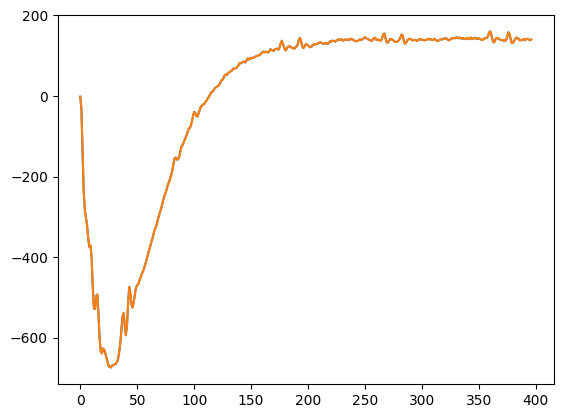

In [ ]:
import matplotlib.pyplot as plt

plt.plot(values[0])
plt.plot(values_stacked[0,:])

In [ ]:
waveform.

(76,)